# Tokenization Methods for NLP

## Introduction

**Tokenization** is the fundamental first step in all natural language processing (NLP) tasks. Before a model can understand or generate text, we must convert raw text (strings) into numerical sequences that neural networks can process.

### What We'll Learn

This notebook explores **four major tokenization approaches** that form the foundation of all modern NLP systems:

1. **Character-level tokenization** - treating each character as a token
2. **Word-level tokenization** - splitting text into words
3. **Subword tokenization (BPE)** - splitting into frequently occurring character sequences
4. **WordPiece tokenization** - BERT's approach to subwords

### Why This Matters

The choice of tokenization method critically affects:
- **Vocabulary size** (memory and computational costs)
- **Out-of-vocabulary (OOV) handling** (dealing with unknown words)
- **Semantic granularity** (capturing meaning at the right level)
- **Model performance** (some tasks prefer certain granularities)

By understanding these trade-offs, you'll know which tokenization approach to use for different NLP tasks.

## Setup

Let's import the necessary libraries and set up our environment for reproducible experiments.

In [1]:
# Standard library
from collections import Counter, defaultdict
import re

# Third-party
import matplotlib.pyplot as plt
import numpy as np

# Our shared library
from aiml_notebooks import CharacterTokenizer, WordTokenizer, set_seed

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

Set the random seed for reproducibility across all experiments.

In [2]:
set_seed(42)

### Sample Text Corpus

We'll use a small corpus of sentences to demonstrate each tokenization method. This corpus includes common words, rare words, and variations to highlight different tokenization behaviors.

In [3]:
# Sample corpus with diverse vocabulary
corpus = [
    "The quick brown fox jumps over the lazy dog.",
    "Machine learning is transforming artificial intelligence.",
    "Tokenization is the first step in natural language processing.",
    "The transformer architecture revolutionized deep learning.",
    "Neural networks learn representations from data.",
    "Preprocessing text involves tokenization and normalization.",
    "The quick fox and the lazy dog became friends.",
    "Transformers use attention mechanisms for processing.",
]

# Test sentence with out-of-vocabulary words
test_sentence = "The superintelligent transformer preprocessed unconventional text."

print(f"Corpus size: {len(corpus)} sentences")
print(f"\nTest sentence: {test_sentence}")

Corpus size: 8 sentences

Test sentence: The superintelligent transformer preprocessed unconventional text.


---

## 1. Character-Level Tokenization

### Intuition

The simplest tokenization approach: **treat every character as a separate token**.

**How it works:**
- "hello" → ['h', 'e', 'l', 'l', 'o']
- Each character (letters, spaces, punctuation) gets its own ID

**Advantages:**
- **Tiny vocabulary** (~100 characters for English)
- **No OOV problem** - can represent any word with existing characters
- **Memory efficient** - minimal token embedding table

**Disadvantages:**
- **Long sequences** - "hello" becomes 5 tokens instead of 1
- **Weak semantics** - characters have little meaning individually
- **Harder to learn** - models must learn to compose characters into words

### Implementation

Let's use the `CharacterTokenizer` from our shared library to tokenize text at the character level.

In [4]:
# Build character tokenizer from corpus
char_tokenizer = CharacterTokenizer(corpus)

print(f"Character vocabulary size: {char_tokenizer.vocab_size}")
print(f"\nFirst 20 characters in vocabulary:")
print(''.join(char_tokenizer.chars[:20]))

Character vocabulary size: 33

First 20 characters in vocabulary:
. .MNPTabcdefghijklm


### Visualization

Let's see how character tokenization encodes our test sentence into token IDs.

In [5]:
# Encode test sentence
char_tokens = char_tokenizer.encode(test_sentence)

print(f"Original text ({len(test_sentence)} chars):")
print(f"  '{test_sentence}'")
print(f"\nTokenized ({len(char_tokens)} tokens):")
print(f"  {char_tokens[:30]}...")
print(f"\nDecoded (first 30 characters):")
decoded_chars = char_tokenizer.decode(char_tokens[:30])
print(f"  '{decoded_chars}'")

Original text (66 chars):
  'The superintelligent transformer preprocessed unconventional text.'

Tokenized (66 tokens):
  [6, 14, 11, 1, 25, 27, 22, 11, 24, 15, 20, 26, 11, 18, 18, 15, 13, 11, 20, 26, 1, 26, 24, 7, 20, 25, 12, 21, 24, 19]...

Decoded (first 30 characters):
  'The superintelligent transform'


### Key Insight

Character tokenization creates a **1:1 mapping** between input text and tokens - every character becomes exactly one token. This guarantees no OOV words, but creates very long sequences that models must process.

---

## 2. Word-Level Tokenization

### Intuition

A more intuitive approach: **split text into words** (typically on whitespace and punctuation).

**How it works:**
- "hello world!" → ['hello', 'world', '!']
- Each unique word gets its own ID

**Advantages:**
- **Strong semantics** - words carry meaning
- **Short sequences** - efficient for models to process
- **Natural boundaries** - aligns with human language understanding

**Disadvantages:**
- **Large vocabulary** - every unique word needs an ID (10k-100k+ tokens)
- **OOV problem** - can't represent words not seen during training
- **Memory intensive** - huge embedding tables
- **Morphology blindness** - "run", "running", "ran" are completely separate

### Implementation

Let's use the `WordTokenizer` from our shared library. It splits on whitespace and handles punctuation.

In [6]:
# Build word tokenizer from corpus
word_tokenizer = WordTokenizer()
word_tokenizer.build_vocab(corpus)

print(f"Word vocabulary size: {word_tokenizer.vocab_size}")
print(f"\nFirst 20 words in vocabulary:")
# Get first 20 words from word_to_idx dictionary
vocab_words = list(word_tokenizer.word_to_idx.keys())[:20]
print(vocab_words)

Word vocabulary size: 49

First 20 words in vocabulary:
['<PAD>', '<UNK>', 'The', 'the', 'quick', 'fox', 'lazy', 'is', 'processing.', 'and', 'brown', 'jumps', 'over', 'dog.', 'Machine', 'learning', 'transforming', 'artificial', 'intelligence.', 'Tokenization']


### Visualization

Let's tokenize the same test sentence and compare the sequence length to character tokenization.

In [7]:
# Encode test sentence
word_tokens = word_tokenizer.encode(test_sentence)

print(f"Original text:")
print(f"  '{test_sentence}'")
print(f"\nTokenized as words ({len(word_tokens)} tokens):")
words = test_sentence.lower().replace('.', ' .').split()
for i, word in enumerate(words):
    token_id = word_tokens[i] if i < len(word_tokens) else "<UNK>"
    print(f"  {i+1}. '{word}' → {token_id}")

print(f"\nSequence length comparison:")
print(f"  Character tokens: {len(char_tokens)}")
print(f"  Word tokens: {len(word_tokens)}")
print(f"  Compression ratio: {len(char_tokens)/len(word_tokens):.1f}x")

Original text:
  'The superintelligent transformer preprocessed unconventional text.'

Tokenized as words (6 tokens):
  1. 'the' → 2
  2. 'superintelligent' → 1
  3. 'transformer' → 25
  4. 'preprocessed' → 1
  5. 'unconventional' → 1
  6. 'text' → 1
  7. '.' → <UNK>

Sequence length comparison:
  Character tokens: 66
  Word tokens: 6
  Compression ratio: 11.0x


### Handling Out-of-Vocabulary (OOV) Words

Word tokenizers face the **OOV problem** - what happens when we encounter a word not in our vocabulary?

In [8]:
# Test with completely new words
oov_sentence = "Superintelligent xenobots communicate telepathically."
oov_tokens = word_tokenizer.encode(oov_sentence)

print(f"OOV test sentence:")
print(f"  '{oov_sentence}'")
print(f"\nTokenized:")
for i, word in enumerate(oov_sentence.lower().replace('.', ' .').split()):
    in_vocab = word in word_tokenizer.word_to_idx
    status = "✓ in vocab" if in_vocab else "✗ OOV → <UNK>"
    print(f"  '{word}': {status}")

OOV test sentence:
  'Superintelligent xenobots communicate telepathically.'

Tokenized:
  'superintelligent': ✗ OOV → <UNK>
  'xenobots': ✗ OOV → <UNK>
  'communicate': ✗ OOV → <UNK>
  'telepathically': ✗ OOV → <UNK>
  '.': ✗ OOV → <UNK>


### Key Insight

Word tokenization provides **semantic meaning** but at the cost of a **large vocabulary** and **poor OOV handling**. Words like "superintelligent" that weren't in the training corpus become unknown tokens, losing all information. This motivated the development of subword tokenization.

---

## 3. Byte Pair Encoding (BPE)

### Intuition

**BPE is the sweet spot between character and word tokenization.** It learns a vocabulary of frequently occurring character sequences (subwords).

**How it works:**
1. Start with all individual characters as tokens
2. **Iteratively merge** the most frequent adjacent token pair
3. Repeat until desired vocabulary size is reached

**Example evolution:**
```
Initial:    ['l', 'o', 'w', 'e', 's', 't']  ← all characters
Merge 1:    ['lo', 'w', 'e', 's', 't']      ← merged 'l'+'o'
Merge 2:    ['lo', 'w', 'es', 't']          ← merged 'e'+'s'
Merge 3:    ['low', 'es', 't']              ← merged 'lo'+'w'
Merge 4:    ['low', 'est']                  ← merged 'es'+'t'
```

**Advantages:**
- **Balanced vocabulary** - not too small, not too large (typically 10k-50k)
- **No OOV problem** - can decompose any word into characters worst-case
- **Captures morphology** - learns prefixes/suffixes like "un-", "-ing", "-est"
- **Efficient sequences** - shorter than characters, more flexible than words

**Disadvantages:**
- **Training required** - must learn merges from corpus
- **Arbitrary boundaries** - splits may not align with linguistic units

### Implementation

Let's build a simple BPE tokenizer from scratch to understand how the merge algorithm works.

In [9]:
class SimpleBPETokenizer:
    """Simple Byte Pair Encoding tokenizer implementation."""
    
    def __init__(self, num_merges=50):
        self.num_merges = num_merges
        self.merges = {}  # Maps (token_a, token_b) -> merged_token
        self.vocab = set()
    
    def _get_word_tokens(self, text):
        """Convert text to word-level character lists."""
        words = text.lower().split()
        # Add end-of-word marker to distinguish word boundaries
        word_tokens = {}
        for word in words:
            # Represent each word as list of characters with </w> marker
            chars = list(word) + ['</w>']
            word_key = ' '.join(chars)
            word_tokens[word_key] = word_tokens.get(word_key, 0) + 1
        return word_tokens
    
    def _get_pair_frequencies(self, word_tokens):
        """Count frequencies of adjacent token pairs."""
        pairs = defaultdict(int)
        for word, freq in word_tokens.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i+1])] += freq
        return pairs
    
    def _merge_pair(self, pair, word_tokens):
        """Merge all occurrences of a token pair in the vocabulary."""
        new_word_tokens = {}
        bigram = ' '.join(pair)
        replacement = ''.join(pair)
        
        for word in word_tokens:
            # Replace all occurrences of the pair
            new_word = word.replace(bigram, replacement)
            new_word_tokens[new_word] = word_tokens[word]
        
        return new_word_tokens
    
    def train(self, corpus):
        """Learn BPE merges from corpus."""
        # Start with character-level representation
        text = ' '.join(corpus)
        word_tokens = self._get_word_tokens(text)
        
        # Build initial vocabulary (all characters)
        for word in word_tokens:
            self.vocab.update(word.split())
        
        print(f"Initial vocabulary size: {len(self.vocab)}")
        print(f"Learning {self.num_merges} merges...\n")
        
        # Iteratively merge most frequent pairs
        for i in range(self.num_merges):
            pairs = self._get_pair_frequencies(word_tokens)
            if not pairs:
                break
            
            # Find most frequent pair
            best_pair = max(pairs, key=pairs.get)
            
            # Merge the pair
            word_tokens = self._merge_pair(best_pair, word_tokens)
            self.merges[best_pair] = ''.join(best_pair)
            self.vocab.add(''.join(best_pair))
            
            # Show first few merges
            if i < 10:
                print(f"Merge {i+1}: ('{best_pair[0]}', '{best_pair[1]}') → '{self.merges[best_pair]}' (freq: {pairs[best_pair]})")
        
        print(f"\nFinal vocabulary size: {len(self.vocab)}")
    
    def encode(self, text):
        """Encode text using learned BPE merges."""
        word_tokens = self._get_word_tokens(text)
        
        # Apply merges in the order they were learned
        for pair in self.merges:
            word_tokens = self._merge_pair(pair, word_tokens)
        
        # Extract all tokens
        tokens = []
        for word in word_tokens:
            tokens.extend(word.split())
        
        return tokens

# Create and train BPE tokenizer
bpe_tokenizer = SimpleBPETokenizer(num_merges=50)
bpe_tokenizer.train(corpus)

Initial vocabulary size: 28
Learning 50 merges...

Merge 1: ('e', '</w>') → 'e</w>' (freq: 11)
Merge 2: ('i', 'n') → 'in' (freq: 10)
Merge 3: ('s', '</w>') → 's</w>' (freq: 8)
Merge 4: ('.', '</w>') → '.</w>' (freq: 8)
Merge 5: ('a', 'n') → 'an' (freq: 7)
Merge 6: ('t', 'i') → 'ti' (freq: 7)
Merge 7: ('t', 'h') → 'th' (freq: 6)
Merge 8: ('th', 'e</w>') → 'the</w>' (freq: 6)
Merge 9: ('f', 'o') → 'fo' (freq: 6)
Merge 10: ('in', 'g') → 'ing' (freq: 6)

Final vocabulary size: 78


### Visualization

Let's see how BPE tokenizes our test sentence and compare it to character and word tokenization.

In [10]:
# Encode test sentence with BPE
bpe_tokens = bpe_tokenizer.encode(test_sentence)

print(f"Original text:")
print(f"  '{test_sentence}'")
print(f"\nBPE tokenization ({len(bpe_tokens)} tokens):")
print(f"  {bpe_tokens}")
print(f"\nSequence length comparison:")
print(f"  Character tokens: {len(char_tokens)}")
print(f"  Word tokens: {len(word_tokens)}")
print(f"  BPE tokens: {len(bpe_tokens)}")

Original text:
  'The superintelligent transformer preprocessed unconventional text.'

BPE tokenization (34 tokens):
  ['the</w>', 's', 'u', 'p', 'er', 'in', 'te', 'l', 'l', 'i', 'g', 'en', 't', '</w>', 'transform', 'er</w>', 'p', 're', 'process', 'e', 'd</w>', 'u', 'n', 'c', 'o', 'n', 'v', 'en', 'tion', 'al</w>', 'te', 'x', 't', '.</w>']

Sequence length comparison:
  Character tokens: 66
  Word tokens: 6
  BPE tokens: 34


### Understanding BPE Splits

Let's examine how BPE handles complex words by looking at how it splits morphologically rich words.

In [11]:
# Test words with clear morphology
test_words = [
    "preprocessing",
    "unconventional",
    "superintelligent",
    "transformer",
]

print("How BPE splits morphologically complex words:\n")
for word in test_words:
    tokens = bpe_tokenizer.encode(word)
    # Remove </w> markers for readability
    tokens_clean = [t.replace('</w>', '|') for t in tokens]
    print(f"  '{word}' → {tokens_clean}")

How BPE splits morphologically complex words:

  'preprocessing' → ['p', 're', 'process', 'ing|']
  'unconventional' → ['u', 'n', 'c', 'o', 'n', 'v', 'en', 'tion', 'al|']
  'superintelligent' → ['s', 'u', 'p', 'er', 'in', 'te', 'l', 'l', 'i', 'g', 'en', 't', '|']
  'transformer' → ['transform', 'er|']


### Key Insight

BPE automatically discovers **meaningful subword units** like prefixes ("un-", "pre-"), suffixes ("-ing", "-er"), and common roots. This allows it to:
1. **Handle OOV words** by decomposing them into known subwords
2. **Share knowledge** across related words ("transform", "transformer", "transformation")
3. **Keep vocabulary manageable** while maintaining expressiveness

This is why BPE (and variants) power modern NLP models like GPT!

---

## 4. WordPiece Tokenization

### Intuition

**WordPiece** is a variant of BPE used by BERT and many Google models. The key difference: instead of merging based on **frequency**, WordPiece merges based on **likelihood improvement**.

**How it differs from BPE:**

BPE asks: *"Which pair appears most often?"*

WordPiece asks: *"Which merge improves the language model likelihood the most?"*

**Mathematical intuition:**
$$
\text{score}(a, b) = \frac{P(ab)}{P(a) \cdot P(b)}
$$

This measures how much more likely "ab" is to appear together than if "a" and "b" were independent. High scores indicate the pair should be merged.

**Additional feature:** WordPiece uses a special `##` prefix to mark subword continuations:
- "playing" → ["play", "##ing"]
- This helps distinguish word beginnings from continuations

### Implementation

Let's implement a simplified WordPiece tokenizer that uses the likelihood-based scoring approach.

In [12]:
class SimpleWordPieceTokenizer:
    """Simplified WordPiece tokenizer with likelihood-based merging."""
    
    def __init__(self, num_merges=50):
        self.num_merges = num_merges
        self.vocab = set()
        self.merges = {}
    
    def _get_word_tokens(self, text):
        """Convert text to word-level character lists with ## markers."""
        words = text.lower().split()
        word_tokens = {}
        for word in words:
            # First character has no prefix, others get ##
            chars = [word[0]] + [f'##{c}' for c in word[1:]]
            word_key = ' '.join(chars)
            word_tokens[word_key] = word_tokens.get(word_key, 0) + 1
        return word_tokens
    
    def _get_token_frequencies(self, word_tokens):
        """Count individual token frequencies."""
        token_freq = defaultdict(int)
        for word, freq in word_tokens.items():
            for token in word.split():
                token_freq[token] += freq
        return token_freq
    
    def _get_pair_scores(self, word_tokens, token_freq):
        """Calculate likelihood-based scores for token pairs."""
        pair_freq = defaultdict(int)
        
        # Count pair frequencies
        for word, freq in word_tokens.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pair_freq[(symbols[i], symbols[i+1])] += freq
        
        # Calculate likelihood scores
        pair_scores = {}
        for (a, b), freq in pair_freq.items():
            # Score = P(ab) / (P(a) * P(b))
            # Higher score means the pair is more "cohesive"
            score = freq / (token_freq[a] * token_freq[b])
            pair_scores[(a, b)] = score
        
        return pair_scores
    
    def _merge_pair(self, pair, word_tokens):
        """Merge all occurrences of a token pair."""
        new_word_tokens = {}
        bigram = ' '.join(pair)
        # Remove ## prefix when merging
        replacement = pair[0] + pair[1].replace('##', '')
        
        for word in word_tokens:
            new_word = word.replace(bigram, replacement)
            new_word_tokens[new_word] = word_tokens[word]
        
        return new_word_tokens
    
    def train(self, corpus):
        """Learn WordPiece merges from corpus."""
        text = ' '.join(corpus)
        word_tokens = self._get_word_tokens(text)
        
        # Build initial vocabulary
        for word in word_tokens:
            self.vocab.update(word.split())
        
        print(f"Initial vocabulary size: {len(self.vocab)}")
        print(f"Learning {self.num_merges} merges...\n")
        
        # Iteratively merge based on likelihood scores
        for i in range(self.num_merges):
            token_freq = self._get_token_frequencies(word_tokens)
            pair_scores = self._get_pair_scores(word_tokens, token_freq)
            
            if not pair_scores:
                break
            
            # Find highest scoring pair
            best_pair = max(pair_scores, key=pair_scores.get)
            
            # Merge the pair
            word_tokens = self._merge_pair(best_pair, word_tokens)
            merged = best_pair[0] + best_pair[1].replace('##', '')
            self.merges[best_pair] = merged
            self.vocab.add(merged)
            
            # Show first few merges
            if i < 10:
                print(f"Merge {i+1}: ('{best_pair[0]}', '{best_pair[1]}') → '{merged}' (score: {pair_scores[best_pair]:.4f})")
        
        print(f"\nFinal vocabulary size: {len(self.vocab)}")
    
    def encode(self, text):
        """Encode text using learned WordPiece merges."""
        word_tokens = self._get_word_tokens(text)
        
        # Apply merges
        for pair in self.merges:
            word_tokens = self._merge_pair(pair, word_tokens)
        
        # Extract tokens
        tokens = []
        for word in word_tokens:
            tokens.extend(word.split())
        
        return tokens

# Train WordPiece tokenizer
wp_tokenizer = SimpleWordPieceTokenizer(num_merges=50)
wp_tokenizer.train(corpus)

Initial vocabulary size: 40
Learning 50 merges...

Merge 1: ('o', '##v') → 'ov' (score: 0.2500)
Merge 2: ('##z', '##y') → '##zy' (score: 0.1667)
Merge 3: ('q', '##u') → 'qu' (score: 0.1250)
Merge 4: ('j', '##u') → 'ju' (score: 0.1667)
Merge 5: ('ju', '##m') → 'jum' (score: 0.1250)
Merge 6: ('jum', '##p') → 'jump' (score: 0.2000)
Merge 7: ('t', '##h') → 'th' (score: 0.0556)
Merge 8: ('##c', '##h') → '##ch' (score: 0.0833)
Merge 9: ('s', '##t') → 'st' (score: 0.0526)
Merge 10: ('jump', '##s') → 'jumps' (score: 0.0476)

Final vocabulary size: 90


### Visualization

Let's compare how WordPiece tokenizes text compared to BPE, paying attention to the `##` markers.

In [13]:
# Encode test sentence
wp_tokens = wp_tokenizer.encode(test_sentence)

print(f"Original text:")
print(f"  '{test_sentence}'")
print(f"\nWordPiece tokenization ({len(wp_tokens)} tokens):")
print(f"  {wp_tokens}")
print(f"\nNotice the ## prefix on subword continuations!")

Original text:
  'The superintelligent transformer preprocessed unconventional text.'

WordPiece tokenization (54 tokens):
  ['th', '##e', 's', '##u', '##p', '##e', '##r', '##i', '##n', '##t', '##e', '##llig', '##e', '##n', '##t', 't', '##r', '##a', '##n', '##sfo', '##r', '##m', '##e', '##r', 'p', '##r', '##e', '##p', '##r', '##o', '##c', '##e', '##s', '##s', '##e', '##d', 'u', '##n', '##c', '##o', '##n', '##v', '##e', '##n', '##t', '##i', '##o', '##n', '##al', 't', '##e', '##x', '##t', '##.']

Notice the ## prefix on subword continuations!


### WordPiece vs BPE on Complex Words

Let's compare how the two subword methods handle the same complex words.

In [14]:
# Test morphologically complex words
test_words = ["preprocessing", "transformer", "unconventional"]

print("Comparing BPE vs WordPiece on complex words:\n")
for word in test_words:
    bpe_toks = bpe_tokenizer.encode(word)
    wp_toks = wp_tokenizer.encode(word)
    
    # Clean up for display
    bpe_clean = [t.replace('</w>', '') for t in bpe_toks]
    
    print(f"'{word}':")
    print(f"  BPE:       {bpe_clean}")
    print(f"  WordPiece: {wp_toks}")
    print()

Comparing BPE vs WordPiece on complex words:

'preprocessing':
  BPE:       ['p', 're', 'process', 'ing']
  WordPiece: ['p', '##r', '##e', '##p', '##r', '##o', '##c', '##e', '##s', '##s', '##i', '##n', '##g']

'transformer':
  BPE:       ['transform', 'er']
  WordPiece: ['t', '##r', '##a', '##n', '##sfo', '##r', '##m', '##e', '##r']

'unconventional':
  BPE:       ['u', 'n', 'c', 'o', 'n', 'v', 'en', 'tion', 'al']
  WordPiece: ['u', '##n', '##c', '##o', '##n', '##v', '##e', '##n', '##t', '##i', '##o', '##n', '##al']



### Key Insight

WordPiece's **likelihood-based scoring** tends to create more **linguistically coherent** subword units compared to BPE's pure frequency approach. The `##` prefix makes it explicit which tokens are word continuations, which helps models understand word boundaries better.

This is why BERT and its variants (RoBERTa, ELECTRA, etc.) use WordPiece tokenization.

---

## Putting It All Together

### Direct Comparison on the Same Text

Let's compare all four tokenization methods on our test sentence to see the trade-offs clearly.

In [15]:
comparison_text = "The transformer preprocessed unconventional text."

# Get tokenizations
char_result = char_tokenizer.encode(comparison_text)
word_result = word_tokenizer.encode(comparison_text)
bpe_result = bpe_tokenizer.encode(comparison_text)
wp_result = wp_tokenizer.encode(comparison_text)

print(f"Text: '{comparison_text}'\n")
print("="*80)
print(f"{'Method':<15} {'Vocab Size':<12} {'Num Tokens':<12} {'Sample Tokens'}")
print("="*80)
print(f"{'Character':<15} {char_tokenizer.vocab_size:<12} {len(char_result):<12} {char_tokenizer.decode(char_result[:20])}...")
print(f"{'Word':<15} {word_tokenizer.vocab_size:<12} {len(word_result):<12} {word_tokenizer.decode(word_result[:5])}...")
print(f"{'BPE':<15} {len(bpe_tokenizer.vocab):<12} {len(bpe_result):<12} {' '.join([t.replace('</w>', '') for t in bpe_result[:5]])}...")
print(f"{'WordPiece':<15} {len(wp_tokenizer.vocab):<12} {len(wp_result):<12} {' '.join(wp_result[:5])}...")
print("="*80)

Text: 'The transformer preprocessed unconventional text.'

Method          Vocab Size   Num Tokens   Sample Tokens
Character       33           49           The transformer prep...
Word            49           5            The transformer <UNK> <UNK> <UNK>...
BPE             78           21           the transform er p re...
WordPiece       90           41           th ##e t ##r ##a...


### Vocabulary Size vs Sequence Length Trade-off

Let's visualize the fundamental trade-off: **vocabulary size** vs **sequence length**.

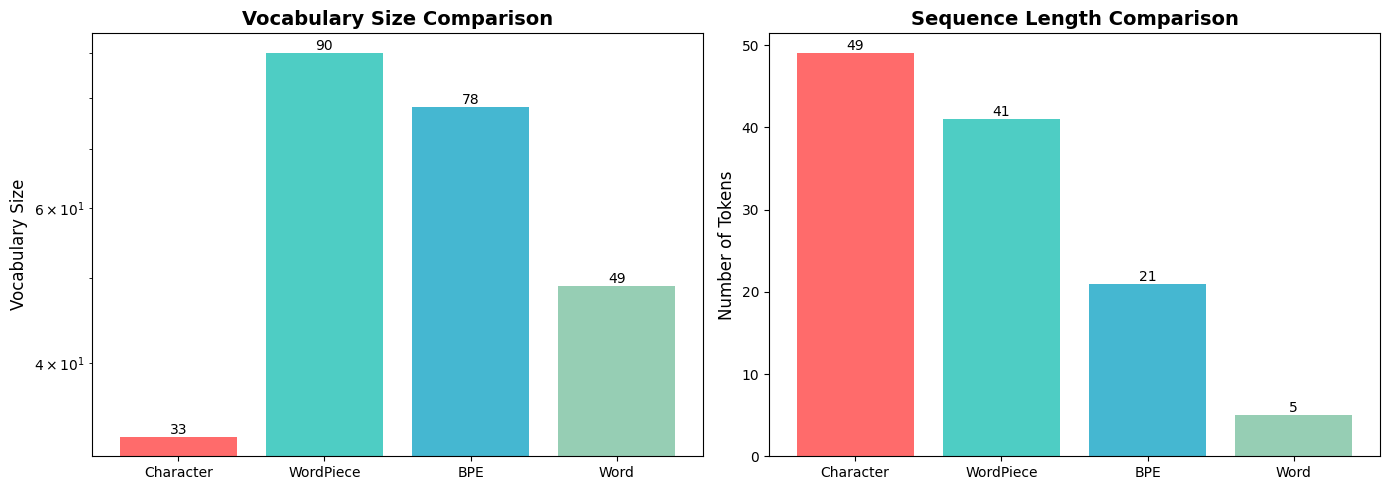


Key observation:
  • Character: tiny vocab, long sequences
  • Word: huge vocab, short sequences
  • BPE/WordPiece: balanced middle ground ✓


In [16]:
methods = ['Character', 'WordPiece', 'BPE', 'Word']
vocab_sizes = [
    char_tokenizer.vocab_size,
    len(wp_tokenizer.vocab),
    len(bpe_tokenizer.vocab),
    word_tokenizer.vocab_size
]
seq_lengths = [
    len(char_result),
    len(wp_result),
    len(bpe_result),
    len(word_result)
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Vocabulary size comparison
ax1.bar(methods, vocab_sizes, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax1.set_ylabel('Vocabulary Size', fontsize=12)
ax1.set_title('Vocabulary Size Comparison', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
for i, v in enumerate(vocab_sizes):
    ax1.text(i, v, f'{v}', ha='center', va='bottom', fontsize=10)

# Sequence length comparison
ax2.bar(methods, seq_lengths, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_ylabel('Number of Tokens', fontsize=12)
ax2.set_title('Sequence Length Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(seq_lengths):
    ax2.text(i, v, f'{v}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey observation:")
print("  • Character: tiny vocab, long sequences")
print("  • Word: huge vocab, short sequences")
print("  • BPE/WordPiece: balanced middle ground ✓")

---

## Experiments & Exploration

### Experiment 1: OOV Handling Stress Test

Let's test how each method handles completely novel words that were never seen during training.

In [17]:
# Completely invented words
novel_text = "The xylophonic metamorphosis of supercalifragilisticexpialidocious."

print(f"Novel text: '{novel_text}'\n")
print("="*80)
print("How each method handles completely novel words:\n")

# Character - always works
char_novel = char_tokenizer.encode(novel_text)
print(f"Character ({len(char_novel)} tokens):")
print(f"  ✓ Successfully tokenized (can handle ANY text)")
print()

# Word - will have OOV issues
word_novel = word_tokenizer.encode(novel_text)
print(f"Word ({len(word_novel)} tokens):")
print(f"  ✗ Novel words become <UNK> (loses information)")
print()

# BPE - decomposes into subwords
bpe_novel = bpe_tokenizer.encode(novel_text)
print(f"BPE ({len(bpe_novel)} tokens):")
print(f"  ✓ Decomposes into subwords: {[t.replace('</w>', '') for t in bpe_novel[:10]]}...")
print()

# WordPiece - also decomposes
wp_novel = wp_tokenizer.encode(novel_text)
print(f"WordPiece ({len(wp_novel)} tokens):")
print(f"  ✓ Decomposes into subwords: {wp_novel[:10]}...")
print("="*80)

Novel text: 'The xylophonic metamorphosis of supercalifragilisticexpialidocious.'

How each method handles completely novel words:

Character (67 tokens):
  ✓ Successfully tokenized (can handle ANY text)

Word (5 tokens):
  ✗ Novel words become <UNK> (loses information)

BPE (56 tokens):
  ✓ Decomposes into subwords: ['the', 'x', 'y', 'l', 'o', 'p', 'h', 'o', 'n', 'ic']...

WordPiece (57 tokens):
  ✓ Decomposes into subwords: ['th', '##e', 'x', '##y', '##l', '##o', '##p', '##h', '##o', '##n']...


### Experiment 2: Morphological Sharing

One key advantage of subword tokenization: **sharing information across morphologically related words**.

In [18]:
# Related words with shared morphology
related_words = [
    "transform",
    "transformer",
    "transforming",
    "transformation",
    "transformed"
]

print("Morphological sharing demonstration:\n")
print("Word tokenization (no sharing):")
for word in related_words:
    tokens = word_tokenizer.encode(word)
    print(f"  '{word}' → token ID {tokens[0] if tokens else '<UNK>'} (separate embeddings)")

print("\nBPE tokenization (shares root 'transform'):")
for word in related_words:
    tokens = bpe_tokenizer.encode(word)
    tokens_clean = [t.replace('</w>', '') for t in tokens]
    print(f"  '{word}' → {tokens_clean}")

print("\nKey insight: BPE/WordPiece can share the 'transform' representation across all variants!")

Morphological sharing demonstration:

Word tokenization (no sharing):
  'transform' → token ID 1 (separate embeddings)
  'transformer' → token ID 25 (separate embeddings)
  'transforming' → token ID 16 (separate embeddings)
  'transformation' → token ID 1 (separate embeddings)
  'transformed' → token ID 1 (separate embeddings)

BPE tokenization (shares root 'transform'):
  'transform' → ['transform', '']
  'transformer' → ['transform', 'er']
  'transforming' → ['transform', 'ing']
  'transformation' → ['transform', 'ation', '']
  'transformed' → ['transform', 'e', 'd']

Key insight: BPE/WordPiece can share the 'transform' representation across all variants!


### Experiment 3: Language Efficiency

Different languages have different characteristics. Let's see how tokenization efficiency varies.

In [19]:
# Test sentences in different languages (same meaning)
multilingual = {
    "English": "hello world, how are you?",
    "German": "hallo welt, wie geht es dir?",  # Compound words common  
    "Finnish": "hei maailma, mita kuuluu?",     # Agglutinative language (simplified)
}

print("Tokenization efficiency across languages:\n")
for lang, text in multilingual.items():
    try:
        char_len = len(char_tokenizer.encode(text))
    except KeyError:
        # Character not in vocab (e.g., non-English characters)
        char_len = "N/A"
    
    word_len = len(word_tokenizer.encode(text))
    bpe_len = len(bpe_tokenizer.encode(text))
    
    print(f"{lang}: '{text}'")
    print(f"  Character: {char_len} tokens | Word: {word_len} tokens | BPE: {bpe_len} tokens")
    print()

Tokenization efficiency across languages:

English: 'hello world, how are you?'
  Character: N/A tokens | Word: 5 tokens | BPE: 23 tokens

German: 'hallo welt, wie geht es dir?'
  Character: N/A tokens | Word: 6 tokens | BPE: 26 tokens

Finnish: 'hei maailma, mita kuuluu?'
  Character: N/A tokens | Word: 4 tokens | BPE: 26 tokens



---

## When to Use Each Method?

### Decision Guide

Choosing the right tokenization method depends on your task, data, and constraints.

In [20]:
# Create a decision matrix visualization
import pandas as pd

decision_matrix = pd.DataFrame({
    'Method': ['Character', 'Word', 'BPE', 'WordPiece'],
    'Vocab Size': ['Tiny (~100)', 'Huge (10k-100k+)', 'Medium (10k-50k)', 'Medium (10k-50k)'],
    'OOV Handling': ['Perfect ✓', 'Poor ✗', 'Excellent ✓', 'Excellent ✓'],
    'Sequence Length': ['Very Long', 'Short', 'Medium', 'Medium'],
    'Best For': [
        'DNA, code, char-level tasks',
        'Simple classification, when vocab is fixed',
        'GPT, general NLP, generation',
        'BERT, understanding tasks'
    ]
})

print("\nTokenization Method Selection Guide:")
print("="*100)
print(decision_matrix.to_string(index=False))
print("="*100)


Tokenization Method Selection Guide:
   Method       Vocab Size OOV Handling Sequence Length                                   Best For
Character      Tiny (~100)    Perfect ✓       Very Long                DNA, code, char-level tasks
     Word Huge (10k-100k+)       Poor ✗           Short Simple classification, when vocab is fixed
      BPE Medium (10k-50k)  Excellent ✓          Medium               GPT, general NLP, generation
WordPiece Medium (10k-50k)  Excellent ✓          Medium                  BERT, understanding tasks


### Practical Recommendations

**Use Character-level when:**
- Working with DNA sequences, code, or structured text
- Need guaranteed zero OOV rate
- Vocabulary is naturally small (e.g., amino acids, musical notes)
- Computational resources allow long sequences

**Use Word-level when:**
- Vocabulary is fixed and small (e.g., classification with known labels)
- Working with controlled language (e.g., command systems)
- Speed is critical and memory is abundant
- You have pre-trained word embeddings (Word2Vec, GloVe)

**Use BPE when:**
- Building generative models (GPT-style)
- Working with multiple languages
- Need balance between vocab size and sequence length
- Want simple, frequency-based approach

**Use WordPiece when:**
- Building understanding models (BERT-style)
- Want linguistically coherent subwords
- Need explicit word boundary markers (##)
- Working with Google's pretrained models

---

## Key Takeaways

### Core Insights

1. **Tokenization is not trivial** - it fundamentally affects what information your model can access and how efficiently it processes text

2. **There's always a trade-off** between vocabulary size and sequence length:
   - Small vocab (char) → long sequences → more computation
   - Large vocab (word) → short sequences → OOV problems
   - **Subwords find the sweet spot** ✓

3. **Subword tokenization dominates modern NLP** because it:
   - Handles OOV words gracefully
   - Shares knowledge across related words
   - Keeps vocabulary manageable
   - Works across languages

4. **BPE vs WordPiece**: Both are excellent
   - BPE: simpler, frequency-based (used by GPT, RoBERTa)
   - WordPiece: likelihood-based, linguistically motivated (used by BERT)

### The Big Picture

Tokenization is the **first step** in the NLP pipeline:

```
Raw Text → Tokenization → Token IDs → Embeddings → Model → Predictions
```

Everything downstream depends on getting this step right. Now that you understand the trade-offs, you're ready to:
- Choose appropriate tokenization for your tasks
- Understand why models like GPT and BERT tokenize the way they do
- Debug tokenization issues in your NLP pipelines
- Move on to learning about **embeddings** (next in TIER 7!)

### Further Exploration

To dive deeper:

1. **Try the Hugging Face tokenizers library** for production-ready implementations:
   ```python
   from transformers import GPT2Tokenizer, BertTokenizer
   ```

2. **Explore SentencePiece** - language-agnostic tokenizer used by many models

3. **Experiment with vocabulary sizes** - see how performance changes with 5k, 10k, 32k, 50k vocabs

4. **Analyze tokenization in multilingual models** - how do they handle diverse scripts?

5. **Next notebook**: `basics-embeddings.ipynb` - learn how tokens become dense vector representations!